## Projeto ciência de dados

## modelo

## Objetivo:

esse estudo busca prever a pontuação da qualidade dos vinhos usando o algoritmo de Random Forest para classificação multiclasse, ou seja, usando um modelo supervisionado de classificação.

primeiro serão exploradas as diferentes características físico-químicas do vinho e qual o impacto de cada uma 

na qualidade dos vinhos e depois será avaliado como o Randon Forest pode ser utilizado para fazer previsões precisas com base nesses dados, apoiando decisões de produção e controle de qualidade.


## Bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import(
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

## base de dados

a base de dados trás a avaliação dos vinhos com base em suas características, são elas:

- **fixed acidity:** acidez fixa do vinho
- **volatile acidity'** acidez volátil
- **'citric acid'** quantidade de ácido cítrico
- **Residual Sugar:** Açúcar residual presente no vinho.
- **Chlorides:** Nível de cloretos.
- **Free Sulfur Dioxide:** Dióxido de enxofre livre no vinho.
- **Total Sulfur Dioxide:** Quantidade total de dióxido de enxofre.
- **Density:** Densidade do vinho.
- **pH:** Nível de pH do vinho.
- **Sulphates:** Quantidade de sulfatos.
- **Alcohol:** Teor alcoólico do vinho.

#### **variável Target:**

- **Quality:** Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.

In [2]:
df = pd.read_csv(r"E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\projeto_M32\winequality-red.csv", delimiter=',')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Análise exploratória (EDA)

## Pré-processamento dos dados

nessa etapa será verificado: 
- o tipo de dados das variáveis,
- dados faltantes para serem tratados na base,
- possíveis outliers,
- distribuição dos dados,
- balanceamento da variável a ser predita,
- importância e correlação das variáveis com o modelo

#### Análise dos tipos dos dados e valores faltantes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


A base possui **1.599 amostras** e **12 variáveis**.

Dataset completo **sem valores faltantes (NaN)** e com tipagem correta dos dados, sendo todas as variáveis explicativas do tipo: **numérica decimal**, e a variável-alvo do tipo: **numérica inteiro (classes)**

### Análise descritiva

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### distribuição dos dados

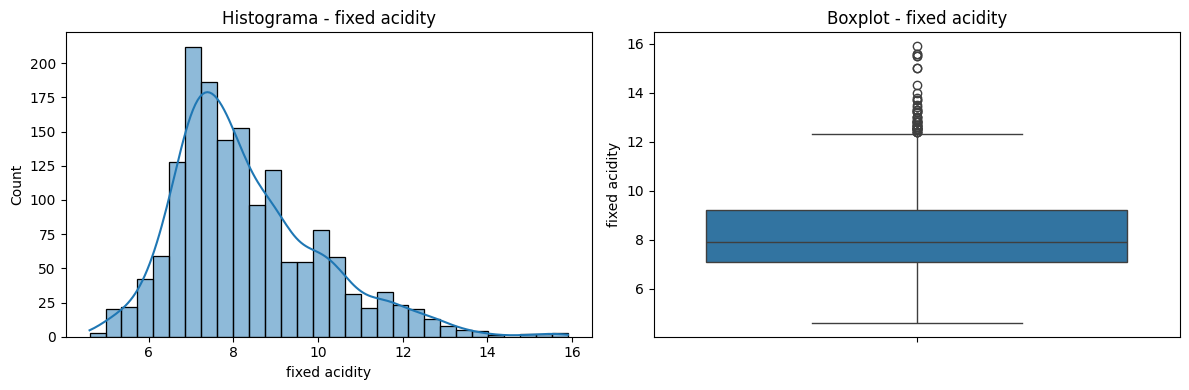

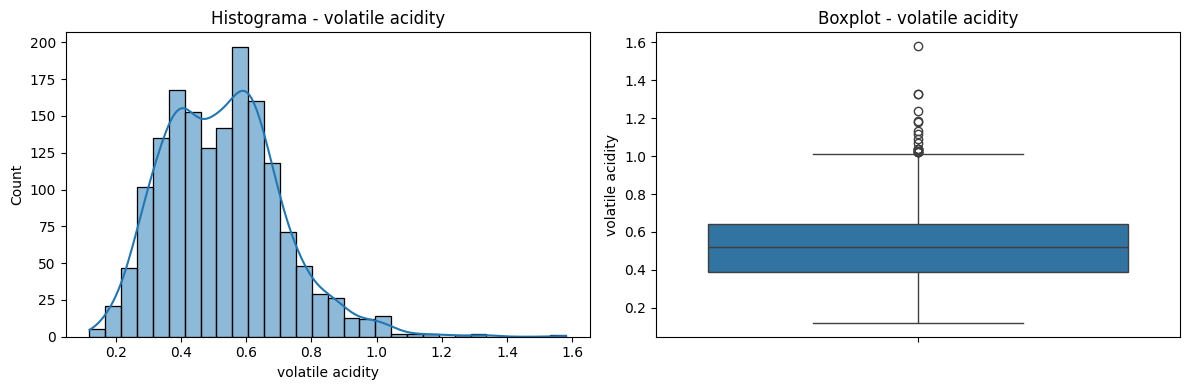

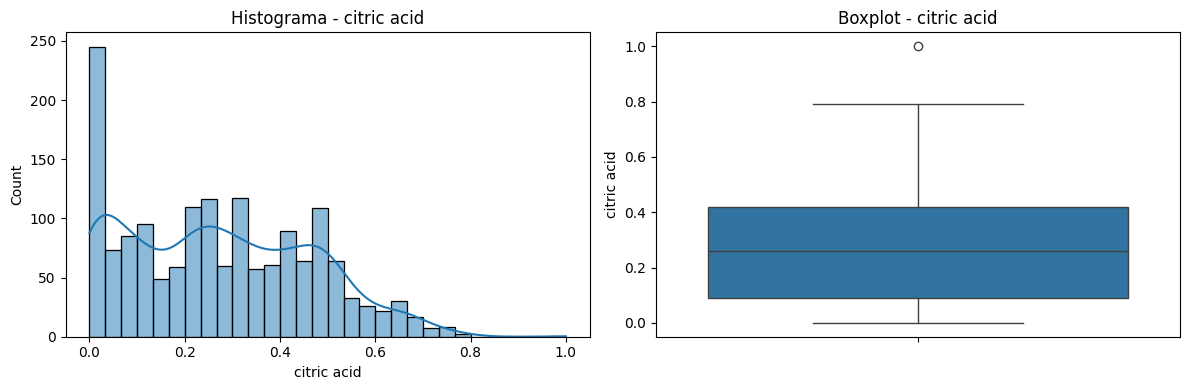

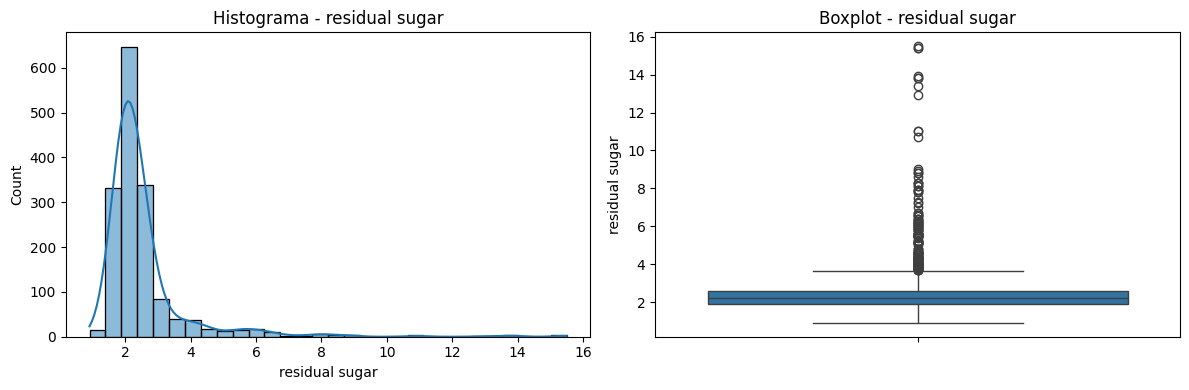

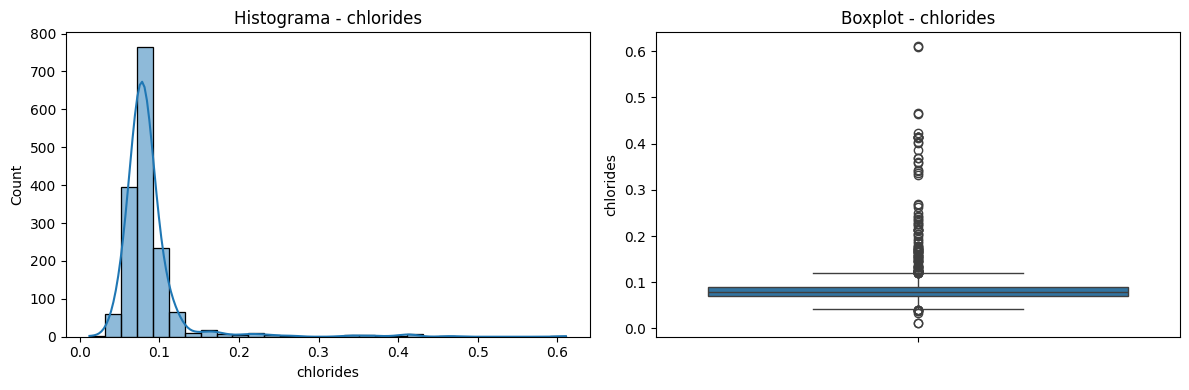

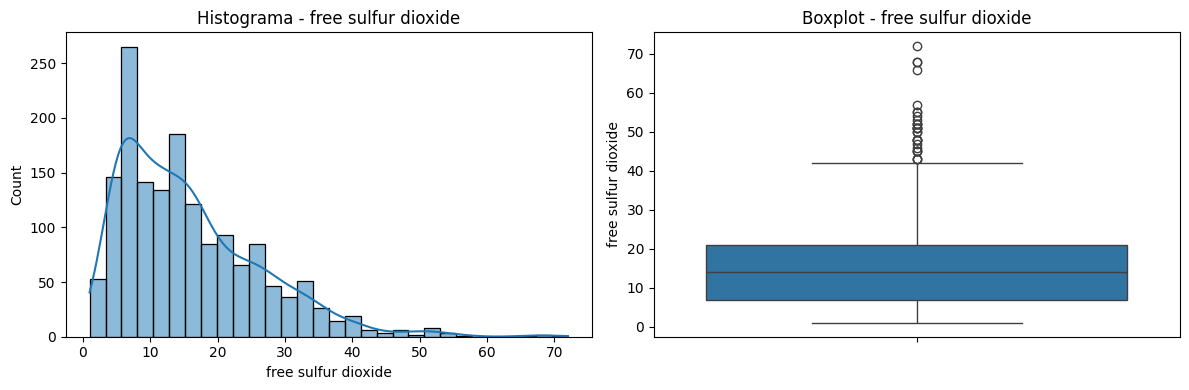

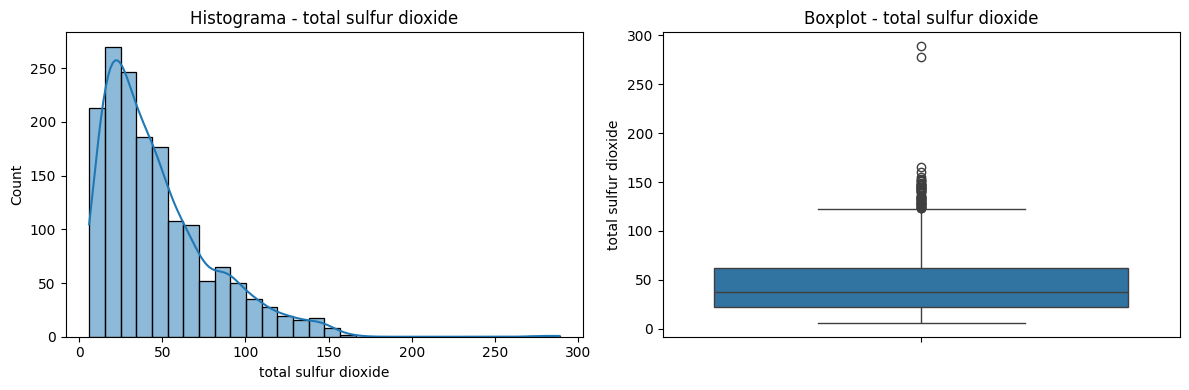

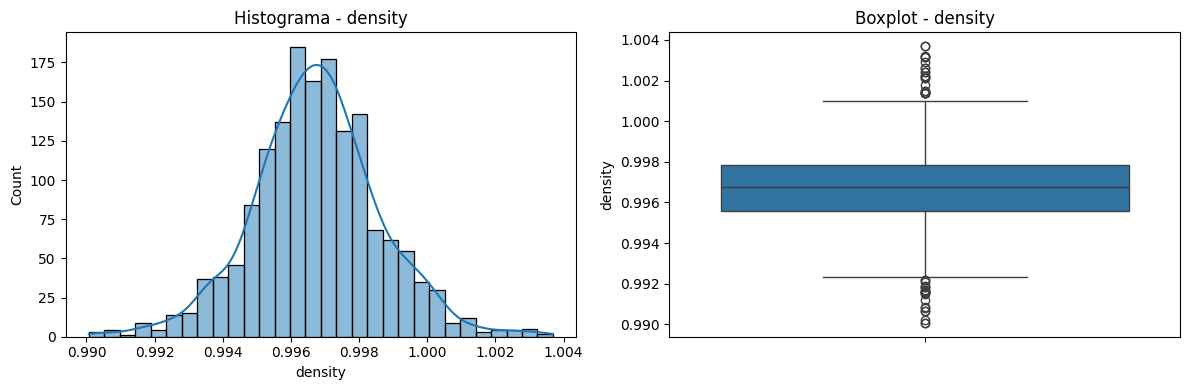

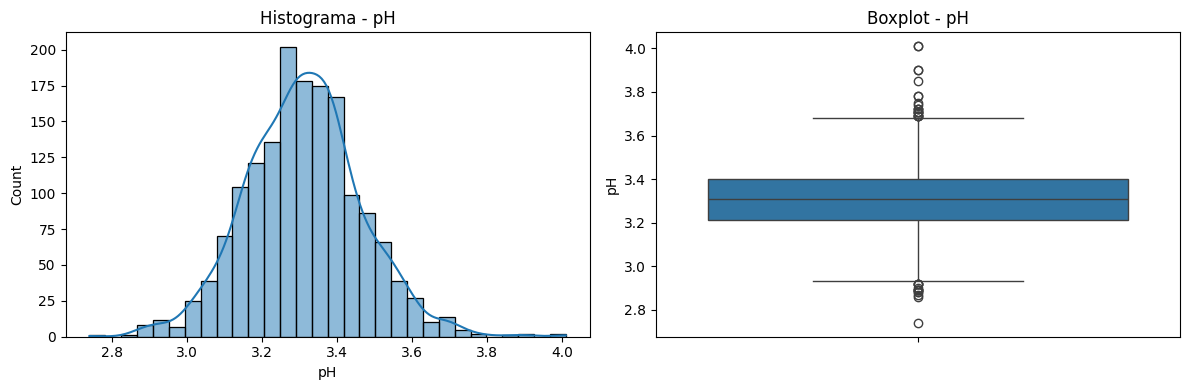

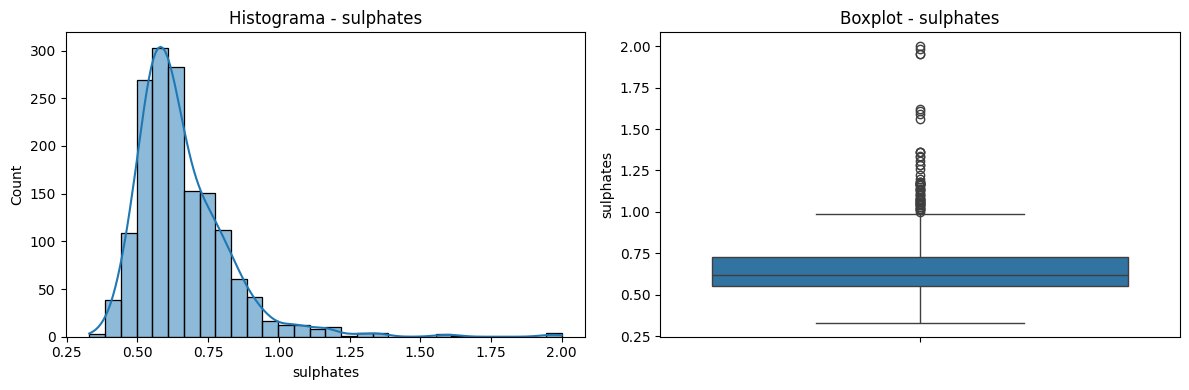

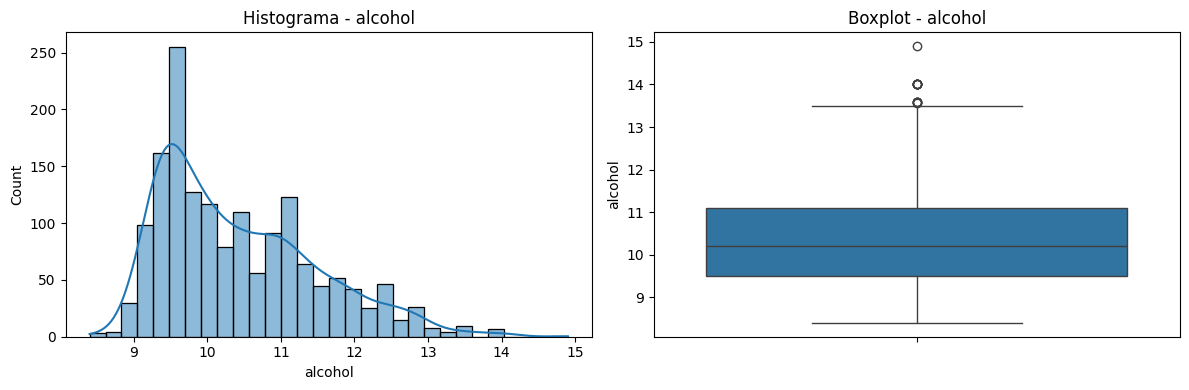

In [5]:
# removendo a variável alvo
features = df.drop('quality', axis=1).columns

# análise das distribuições apenas das variáveis explicativas
for col in features:
    fix, ax = plt.subplots(1, 2, figsize=(12,4))

    #histograma
    sns.histplot(
        df[col], 
        bins=30,
        kde=True,
        ax=ax[0]
    )
    ax[0].set_title(f'Histograma - {col}')

    # boxplot
    sns.boxplot(
        y=df[col],
        ax=ax[1]
    )
    ax[1].set_title(f'Boxplot - {col}')

    plt.tight_layout()  # evita sobreposição
    plt.show

#### Detecção de outliers com IQR (interquartile range)

In [6]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Limites inferior e superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificando outliers
outliers = ((df < limite_inferior) | (df > limite_superior))

outliers_count = outliers.sum().sort_values(ascending=False)

print('NÚMERO DE OUTLIERS: ')
outliers_count

NÚMERO DE OUTLIERS: 


residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
quality                  28
volatile acidity         19
alcohol                  13
citric acid               1
dtype: int64

Foram analisadas as distribuições das variáveis numéricas por meio de histogramas e boxplots.

Observou-se que todas as variáveis apresentam assimetria e presença de valores extremos, o que é esperado considerando a natureza química dos dados de vinhos, 

ou seja, esses valores extremos podem representar variações reais do processo de produção, não necessariamente erros.

Além disso, o algoritmo random forest é menos sensível à outliers, pois árvores não usam distância (como KNN), não assumem distribuição normal e fazem splits baseados em regras.

Portanto, essas observações serão consideradas na etapa de modelagem, especialmente na avaliação de impacto dos outliers sobre o desempenho do modelo e não será feito nenhum tratamento com outliers nesse momento.

#### Balanceamento da variável-alvo

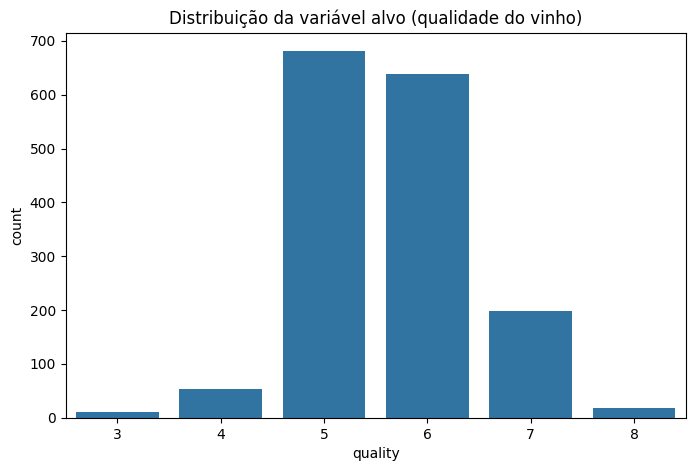

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="quality", data=df)
plt.title("Distribuição da variável alvo (qualidade do vinho)")
plt.show()

In [8]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

**notas 5 e 6** são as mais frequentes na distribuição.

nota-se um desbalanceamento moderado da variável, sendo necessário provavelmente utilização da técnica de SMOTE ou class_weight

#### matriz de correlação das variáveis

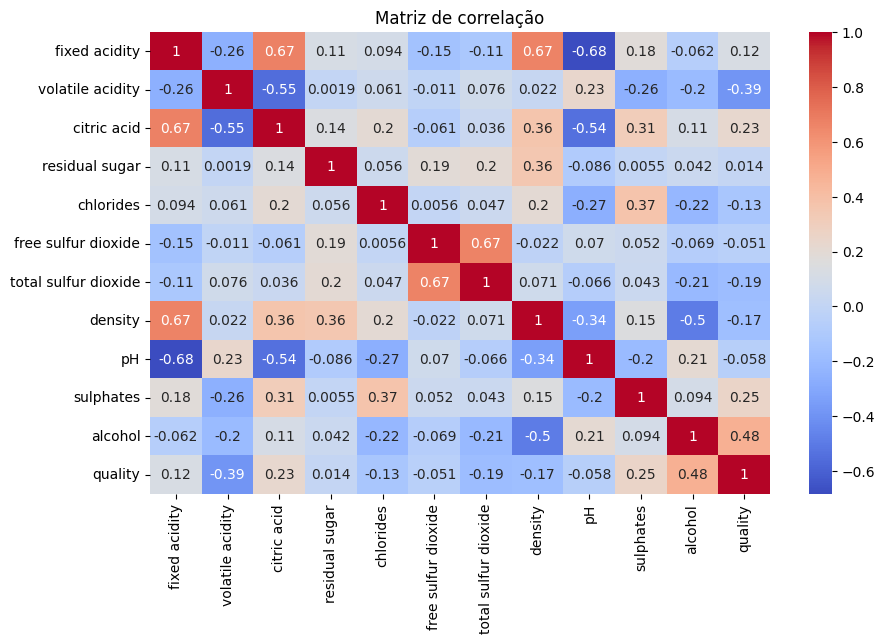

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(), 
    annot=True,
    cmap='coolwarm'
)
plt.title('Matriz de correlação')
plt.show()

#### Relações das features com Target:

Quality x Alcohol: correlação positiva moderada (0.48)

Quality x sulphates: correlação positiva fraca (0.25)

Quality x citric acid: correlação positiva fraca (0.23)

Quality x volatile acidity: correlação negativa moderada -(0.39)

Quality x total sulfur dioxide: correlação negativa fraca -(0.19)

Quality x density: correlação negativa fraca -(0.17)

#### Hipótese 1:

vinhos com maior teor alcoólico tendem a apresentar maior qualidade?

<Axes: xlabel='quality', ylabel='alcohol'>

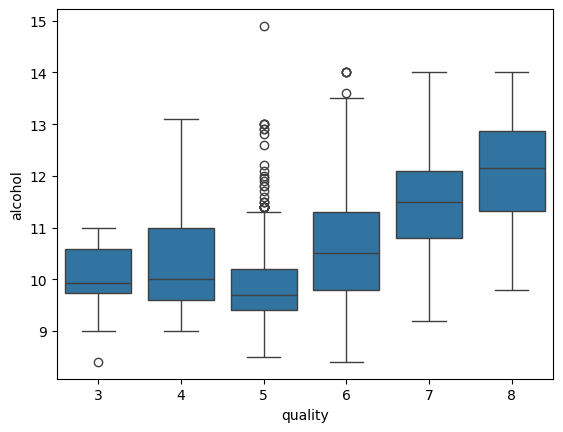

In [10]:
sns.boxplot(
    x='quality', 
    y='alcohol', 
    data=df)

apesar da sobreposição entre as classes, observa-se sim tendência crescente do teor acoólico conforme o aumento da qualidade do vinho.

#### Hipótese 2:

vinhos com maior quantidade de sulfatos tendem a apresentar maior qualidade?

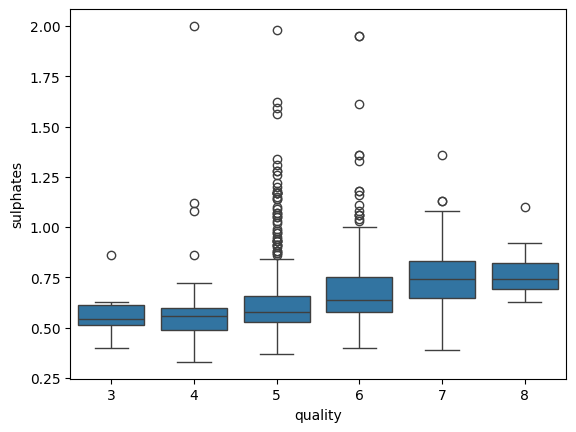

In [11]:
sns.boxplot(
    data=df,
    x= 'quality',
    y= 'sulphates'
)
plt.show()

Observa-se também:

sobreposição entre as classes,

tendência crescente da quantidade de sulfatos conforme o aumento da qualidade do vinho

#### Hipótese 3:

vinhos com menor acidez volátil tendem a apresentar maior qualidade?

In [12]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

<Axes: xlabel='quality', ylabel='volatile acidity'>

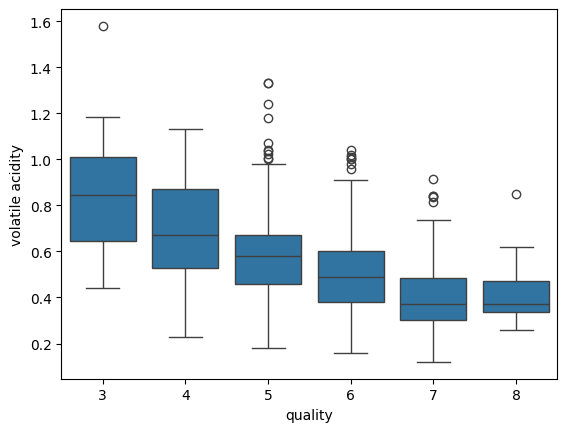

In [13]:
sns.boxplot(
    x= 'quality',
    y= 'volatile acidity',
    data= df
)

Observou-se tendência decrescente na quantidade de acidez volátil conforme aumento da nota de qualidade, indicando uma correlação negativa entre as variáveis.

quanto maior a acidez volátil, menor a pontuação de qualidade.

#### Hipótese 4:

Vinhos com menor quantidade total de dióxido de enxofre tendem a apresentar maior qualidade?

<Axes: xlabel='quality', ylabel='total sulfur dioxide'>

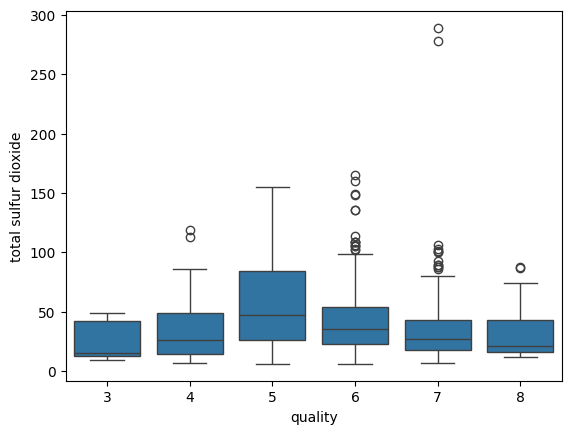

In [14]:
sns.boxplot(
    data= df,
    x= 'quality',
    y= 'total sulfur dioxide'
)

quantidade total de dióxido de enxofre não mostrou tendência na relação com a qualidade, confirmando uma correlação fraca.

essa variável sozinha não discrimina bem os níveis de qualidade, embora as vezes ela possa ajudar em conjunto com outras.

## Conclusões da etapa de análise exploratória de dados

será mantida todas as variáveis para a etapa de modelagem para que o primeiro modelo tenha mais informação e que ele possa fazer suas decisões, 

sendo possível comparar ou com um modelo reduzido ou analisar feature importance e ver se surte diferença após avaliação das métricas de resultado.

## Pré-modelagem

antes de qualquer transformação na base de dados, é necessária primeiramente a separação da base em treino e teste para evitar vazamento de dados

#### split treino / teste

In [15]:
# X são todas as variáveis, menos "qualidade"
X = df.drop('quality', axis= 1)
y = df['quality']

# separação da base
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify= y         # mantem proporção da classe
)

#### Validação das bases separadas

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1199, 11)
(400, 11)
(1199,)
(400,)


Random Forest geralmente se adapta melhor a dados despadronizados em comparação com a regressão logística. Isso ocorre porque o Random Forest é baseado em árvores de decisão, que são menos sensíveis à escala dos dados.

não será aplicada, portanto, a padronização dos dados.

## modelagem

In [17]:
# instanciando o modelo
rf = RandomForestClassifier(
    random_state=42
)

## Cross-validation do treino

o método cross validation no treino, trás uma média de performance mais confiável e menos dependente de um único split.

isso trás uma estimativa boa de performance.

In [18]:
scores = cross_val_score(
    rf, 
    X_train, 
    y_train, 
    cv=5,           # modelo treinado e validado 5 vezes
    scoring='accuracy'
)

#### média de performance

In [19]:
scores.mean()

np.float64(0.6747071129707113)

#### estabilidade do modelo

In [20]:
scores.std()

np.float64(0.020096675635562864)

avaliando como o modelo se comporta em diferentes fatias do treino, o modelo se mostrou estável e mediano em performance

**67% de acurácia média**, indica que o modelo ainda pode melhorar e que talvez as features ainda não capturam bem o fenômeno.

**desvio padrão de 0.020** é excelente para o modelo, consistente, não depende muito da amostra e trás boa generalização.

## Treinamento do modelo

In [21]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Teste - previsões do modelo

In [22]:
y_pred_test = rf.predict(
    X_test
)

## Avaliação do modelo

In [23]:
print(classification_report(
    y_test,
    y_pred_test)
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        13
           5       0.70      0.75      0.72       170
           6       0.61      0.71      0.66       160
           7       0.68      0.42      0.52        50
           8       0.50      0.20      0.29         5

    accuracy                           0.66       400
   macro avg       0.41      0.35      0.36       400
weighted avg       0.63      0.66      0.64       400



c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

O modelo apresenta **acurácia moderada de 66%**, pois o modelo aprendeu as classes frequentes

existe desbalanceamento das classes, o que faz a média macro cair bastante **(0.36)**

o modelo aprende muito bem as classes majoritárias, **5 e 6, com 72% e 66% respectivamente, na média harmônica (f1-score)**

o modelo não consegue identificar as classes raras, indicando um efeito do desbalanceamento 

e confunde as classes intermediárias **(6 e 7)**

In [24]:
print(confusion_matrix(
    y_test,
    y_pred_test
))

[[  0   1   1   0   0   0]
 [  0   0  11   2   0   0]
 [  0   0 127  42   1   0]
 [  0   0  40 113   7   0]
 [  0   0   2  26  21   1]
 [  0   0   0   2   2   1]]


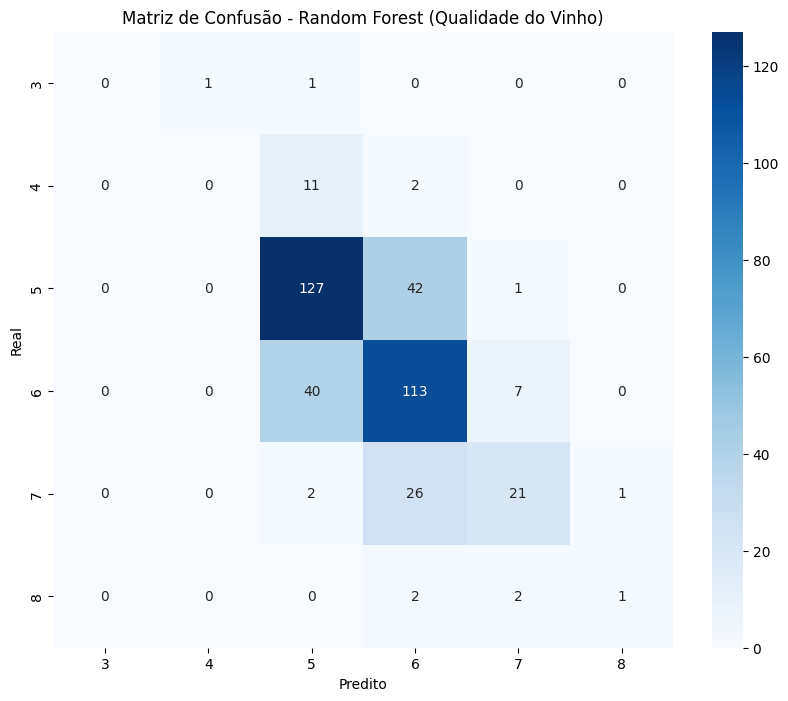

In [25]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred_test, labels=labels)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest (Qualidade do Vinho)")

plt.show()

o modelo confunde classes vizinhas, mas isso indica coerência na ordenação da qualidade:

- 42 casos: 5 sendo previsto como 6.

- 40 casos: 6 sendo previsto como 5.

- 26 casos: 7 sendo previsto como 6.

classes baixas 3 e 4 nunca previstas corretamente e classe alta 8 pouco aprendida.

## Conclusões da avaliação do modelo

O Random Forest apresentou mediano desempenho geral (accuracy de 66%), sendo capaz de prever com boa qualidade as classes mais frequentes (notas 5 e 6).

No entanto, observou-se baixa capacidade de generalização para classes raras, como notas 3, 4 e 8, indicando impacto significativo do desbalanceamento da variável alvo.

A matriz de confusão mostra que os principais erros ocorrem entre classes adjacentes, o que é consistente com a natureza ordinal da variável qualidade.

Dessa forma, o modelo apresenta boa coerência nas previsões, mas necessita de melhorias para capturar melhor as classes menos representadas.

## Pipeline da 2° etapa

Um pipeline organiza todas as etapas do modelo em uma sequência única e reproduzível,

ele é executado dentro de cada fold do cross validation e por isso é crucial, pois:

- não vaza informação,

- cada fold treina do zero,

- tudo reprodutível.

nessa etapa será construido um modelo otimizado e robusto, com o objetivo de tratar os principais problemas do primeiro modelo:

- classes raras ignoradas,

- recall baixo nas extremidades,

- confusão entre classes vizinhas.

no Pipeline será feito: 

- Balanceamento, usando **class_weight='balanced)**

- Construção e otimização do 2° modelo.

In [26]:
pipeline = Pipeline([
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))    # etapa do pipeline
]
)

## Espaço de hiperparâmetros

In [27]:
param_dist = {
    "rf__n_estimators": [100, 200, 300],        # número de árvores na floresta
    "rf__max_depth": [None, 10, 20, 30],            # máxima profundidade ou nenhuma
    "rf__min_samples_split": [2, 5, 10],                # mínimo de amostras necessárias para dividir um nó
    "rf__min_samples_leaf": [1, 2, 4],                      # mínimo de amostras necessárias para dividir um nó folha
    "rf__max_features": ["sqrt", "log2", None],                        # número de recursos a serem considerados para encontrar a melhor divisão, usando raiz (sqrt) ou log ou todas.
    "rf__bootstrap": [True, False]                          # testa se o modelo usa ou não amostragem com reposição nas árvores                          
}

o último parâmetro **bootstrap** define como cada árvore do modelo recebe os dados de treino.

em True:
- padrão, cada árvore é treinada com uma amostra aleatória com reposição da base (bootstrap sampling)

- maior diversidade, menor overfitting, melhor generalização.

em False:
- todas as árvores veem os mesmos dados

- cada árvore usa toda a base de dados original, sem amostragem com repetição.

- menos diversidade, maior overfitting, pode melhorar performance algumas vezes.

## Configuração do **Randomized Search CV**

In [28]:
random_search = RandomizedSearchCV(
    estimator= pipeline,                    # especifica o modelo que deseja otimizar
    param_distributions=param_dist,             # contem o dicionário de hiperparâmetros que serão amostrados
    n_iter=100,                                     # número de combinações diferentes a serem testados
    cv=5,                                       # número de dobras para cross validation
    n_jobs=-1,                              # processa mais rápido
    verbose=2,                          # controla o nível de log
    random_state=42,                # reprodutibilidade
    scoring='f1_macro'                          # média harmônica para decidir quem é melhor
)

com métrica de avaliação **(scoring)** baseada em **F1 macro**, o modelo trata todas as classes igualmente, inclusive as menos representadas.

com f1_macro, o modelo é penalizado fortemente se ignorar as classes raras,

isso força o Random Forest a tentar aprender melhor essas classes.

## Treinamento com Randomized Search CV

In [29]:
# executando
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__bootstrap': [True, False], 'rf__max_depth': [None, 10, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies 

## melhores parâmetros

In [30]:
# Obtendo os melhores hiperparâmetros através do método randomico
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 4, 'rf__max_features': None, 'rf__max_depth': None, 'rf__bootstrap': True}


- melhor número de árvores na floresta: 200

- melhor número de amostras para dividir um nó: 5

- melhor número de amostras para dividir um nó-folha: 4

- melhor número de recursos para encontrar a melhor divisão: todas as features.

- a árvore pode crescer até onde for necessário.

- melhor bootstrap padrão.

## Seleção do melhor modelo

In [31]:
best_model = random_search.best_estimator_

após o treino, quando o modelo encontra as melhores combinações, ele automaticamente treina novamente 

com os melhores parâmetros quando se gera o **best_estimator_**, sendo desnecessário, portanto, treinar novamente.

## Teste do modelo melhorado

nessa etapa será usada a mesma base de teste do primeiro modelo para uma comparação justa dos dois, isso garante uma eventual melhoria real e não aleatória.

a mesma base de teste pode ser usada mais de uma vez para avaliação final, desde que não seja usada para treinar ou ajustar modelos.

In [32]:
y_pred_test2 = best_model.predict(X_test)

## Avaliação e comparação do modelo

In [33]:
print(classification_report(
    y_test, 
    y_pred_test2)
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.50      0.38      0.43        13
           5       0.76      0.72      0.74       170
           6       0.62      0.69      0.65       160
           7       0.58      0.56      0.57        50
           8       0.33      0.20      0.25         5

    accuracy                           0.67       400
   macro avg       0.47      0.43      0.44       400
weighted avg       0.66      0.67      0.66       400



c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

a análise mostra que houve ganho real, principalmente das classes minoritárias,

O modelo Random Forest otimizado apresentou melhora em relação ao modelo baseline, com aumento da acurácia de 66% para 67%.

mais importante que a acurácia, a média macro do F1-score aumentou de 0.36 para 0.44, indicando uma melhora significativa no desempenho do modelo em classes minoritárias

e isso é um ganho muito relevante, pois macro f1 trata todas as classes igualmente, então melhorou, portanto, a equidade do modelo.

evolução da média harmônica (f1-score) das classes:

- classe 3: 0% para 0% - sem evolução da classe 3, pois só há 2 exemplos, dado extremamente escasso e sem padrão para que o modelo aprenda.

- classe 4: de 0% para 43% - aumento significativo da detecção da classe 4, devido ao balanceamento.

- classe 5: de 72% para 74% - leve aumento da classe dominante que manteve boa performance mesmo com balanceamento.

- classe 6: de 66% para 65% - leve queda do modelo atual, o que é esperado ao melhorar outras classes

- classe 7: de 52% para 57% - aumento da detecção de vinhos de qualidade mais alta,

- classe 8: de 29% para 25% - queda do modelo atual, mas é um comportamento esperado pois há pouquíssimos exemplos dessa classe.

Houve pequenas perdas de desempenho nas classes majoritárias (classe 6) e nas classes extremamente raras (classe 8), 

o que representa um trade-off esperado ao utilizar técnicas de balanceamento de classes.

De forma geral, o modelo tornou-se mais equilibrado entre as classes, reduzindo viés para as categorias mais frequentes.

In [34]:
print(confusion_matrix(
    y_test, 
    y_pred_test2)
)

[[  0   1   1   0   0   0]
 [  0   5   5   3   0   0]
 [  0   2 123  44   1   0]
 [  0   2  32 110  16   0]
 [  0   0   1  19  28   2]
 [  0   0   0   1   3   1]]


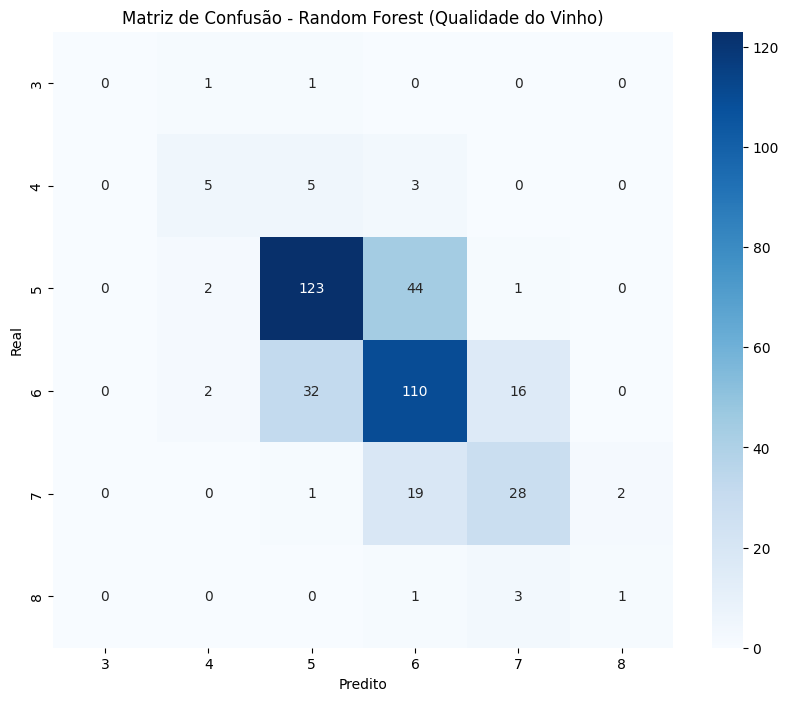

In [35]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred_test2, labels=labels)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest (Qualidade do Vinho)")

plt.show()

o modelo está bem calibrado nas classes dominantes,

o modelo permance errando por proximidade ordinal, mas é um ótimo sinal pois são erros de "degrau de qualidade", não aleatórios.

O modelo não tem dados suficientes para aprender padrões das classes 3 e 8.

Observa-se também melhoria significativa na identificação da classe 4 em comparação ao primeiro modelo, evidenciando o impacto positivo do balanceamento de classes.

## Análise da importância das variáveis (Features Importance)

Nessa etapa analisamos o quanto o modelo usa cada variável para tomar decisão.

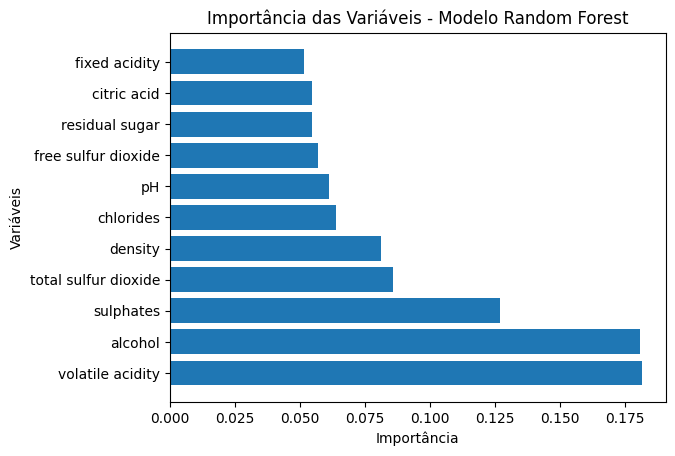

In [36]:
importances = best_model.named_steps['rf'].feature_importances_

features = X.columns

df_importances = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure()
plt.barh(df_importances['feature'], df_importances['importance'])
plt.title('Importância das Variáveis - Modelo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()

As 3 primeiras variáveis já explicam ~49% do modelo,

Isso explica por que o primeiro modelo já estava com uma boa performance.

A análise de importância das variáveis mostrou que a qualidade do vinho é majoritariamente influenciada por:

**- Acidez volátil (volatile acidity):** Maior fator de impacto negativo na qualidade

**- Teor alcoólico (alcohol):** vinhos com maior teor tendem a ser melhor avaliados

**- Sulfatos (sulphates):** relacionados à preservação e estabilidade do vinho

- Variáveis com menor impacto: fixed acidity, citric acid, residual sugar

ajustes nessas variáveis têm impacto limitado na percepção final de qualidade.

**Os resultados permitem direcionar ações práticas na produção:**

Controle rigoroso da acidez volátil

Ajustes no processo de fermentação para otimização do teor alcoólico

Gestão adequada do uso de sulfatos

Essas ações podem contribuir diretamente para o aumento da qualidade do produto final.

## Técnicas possíveis de melhoria

Transformar o problema em regressão, usando **Random Forest Regressor**

ou agrupar classes raras (3-4, 5-6 e 7-8) para classe baixa, média e alta, transformando em um problema de 3 classes, reduzindo balanceamento e melhorando recall das classes raras.

testar hiperparâmetros, ajustando **max_features** ou aumentando **n_estimator** por exemplo.

utilizar outro método de balanceamento, como SMOTE, por exemplo.

Coletar mais dados das classes extremas ou criar novas variáveis que podem revelar padrões escondidos **(feature engineering)

Análise da feature importance do modelo otimizado e observar quais características mais impactam a qualidade do vinho.

## Conclusão

O modelo desenvolvido apresenta boa performance geral e mostrou ganhos relevantes na identificação de classes menos frequentes, especialmente notas intermediárias,

apesar de ainda haver dificuldade na distinção entre notas muito próximas, o modelo já demonstra capacidade prática de apoio à decisão, podendo ser utilizado como base para análises e recomendações.

com evolução futura de dados e ajustes adicionais, o modelo tem potencial de atingir níveis ainda mais altos de performance, pronto para a etapa de interpretação e refinamento.